# Red neuronal artificial para reconocer el tipo de un pokemon

En esta tarea ustedes deben diseñar, entrenar y evaluar un modelo de red neuronal con arquitectura convolucional para resolver el problema de reconocer el tipo de un pokemon en base a una imagen del mismo y a sus atributos. El principal desafio es el desbalance y poca cantidad de ejemplos en el dataset. 

**RECONOCER EL TIPO DE UN POKEMON EN BASE A LA IMAGEN Y SUS ATRIBUTOS**

A continuación se instancia el dataset y se itera para presentar algunos ejemplos:

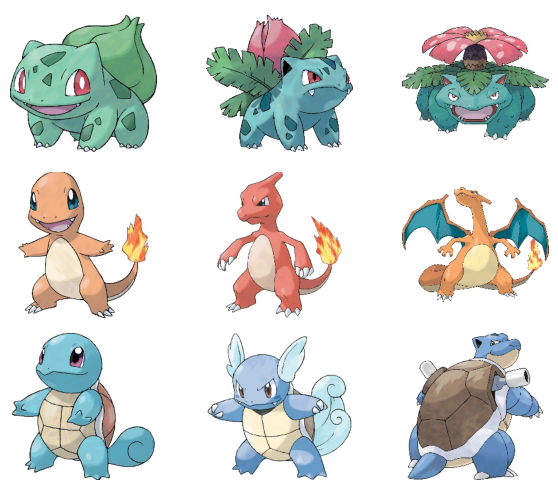

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
import matplotlib.pyplot as plt
from pokemon_utils import PokemonImages

dataset = PokemonImages('data/')

fig, ax = plt.subplots(3, 3, figsize=(7, 5), tight_layout=True)
for ax_, (image, label, name, attributes) in zip(ax.ravel(), dataset):
    ax_.imshow(image.permute(-2, -1, 0))
    ax_.axis('off');

In [2]:
# ── Imports (consolidados) ──────────────────────────────────────────────
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.models as models
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from torch.utils.data import Subset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

Cada ejemplo tiene su imagen, su etiqueta, su nombre y sus atributos:

In [3]:
image, label, name, attributes = dataset[0]
type(image), image.shape, label, name, attributes

(torch.Tensor,
 torch.Size([3, 256, 256]),
 np.int64(9),
 'Bulbasaur',
 tensor([ 0.7000,  6.9000, 45.0000, 49.0000, 49.0000, 45.0000]))

Se puede obtener el nombre de la clase con:

In [4]:
dataset.categories[label]

'Grass'

Y los atributos disponibles son:

In [5]:
dataset.attribute_names

['Height', 'Weight', 'HP', 'Attack', 'Defense', 'Speed']

La cantidad de ejemplos por clase es:

In [6]:
x = Counter(dataset.labels)
for key in sorted(x):
    print(f"{dataset.categories[key]}: {x[key]}")

Bug: 52
Dark: 20
Dragon: 13
Electric: 32
Fairy: 8
Fighting: 20
Fire: 34
Ghost: 18
Grass: 58
Ground: 26
Ice: 19
Normal: 80
Poison: 26
Psychic: 44
Rock: 32
Steel: 17
Water: 96


En lo que sigue utilice los siguientes conjuntos de entrenamiento (train) y prueba (test). 

### Definición del modelo

Defina e implemente un modelo apropiado para el problema. Justifique sus decisiones de diseño.

## Justificación
Para abordar el problema de reconocer usando el tipo con los atributos y la imagen sale más factible usar por un lado una arquitectura CNN para la imagen, y una arquitectura MLP para los atributos.

### CNN (imagen)
En este caso cada imagen es de 3x256x256, lo que tiene un total de 196,608 valores, en una MLP se necesitaría esa cantidad de neuronas en primera capa, lo que es inmanejable. Además como se vió en el curso las CNN son especiales para este tipo de problemas de reconocer patrones en imagenes.

Ahora la arquitectura de este modelo será la siguiente.
Se utilizarán 4 bloques convulcionales(conv2D->Relu->Maxpool2D(2)), esto se hace para que se pueda comprimir lo maximo posible la matriz, pasando de 256x256 a 16x16 de forma gradual dejando un vector de features más conveniente

Se usará un maxpool2D de tamaño 2 porque MaxPool(2) descarta 3 de cada 4 valores, MaxPool(4) descarta 15 de 16. Con un dataset pequeño cada píxel de información cuenta, así que conviene reducir suavemente. Además las capas conv intermedias tienen la oportunidad de aprender features antes de cada compresión.

Se utiliza AdaptiveAvgPool2d(4,4) al final de los bloques para forzar la salida a un tamaño fijo de 128×4×4 = 2048, haciendo el modelo robusto a variaciones de tamaño y reduciendo el vector antes del clasificador.


### MLP (atributos)
Los 6 atributos numéricos (HP, Attack, Defense, Speed, Height, Weight) pasan por una capa Linear(6→32) + ReLU. Simple porque los atributos ya son valores limpios y pocos.
Fusión
Ambas salidas se concatenan (2048 + 32 = 2080) y pasan por un clasificador Linear(2080→256→18) con Dropout(0.5) para regularizar, dado que el dataset es pequeño (~600 imágenes para 18 clases) y el riesgo de overfitting es alto.


In [7]:
class PokemonCNN(nn.Module):

    def __init__(self, num_classes=18, num_attributes=6,attr_mean=None, attr_std=None):
        super().__init__()

        # Rama imagen: 4 bloques Conv → ReLU → MaxPool2d(2)
        # Cada MaxPool divide el spatial por 2: 256→128→64→32→16
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),   # 3×256×256 → 16×256×256
            nn.ReLU(),
            nn.MaxPool2d(2),                               # → 16×128×128

            nn.Conv2d(16, 32, kernel_size=3, padding=1),  # → 32×128×128
            nn.ReLU(),
            nn.MaxPool2d(2),                               # → 32×64×64

            nn.Conv2d(32, 64, kernel_size=3, padding=1),  # → 64×64×64
            nn.ReLU(),
            nn.MaxPool2d(2),                               # → 64×32×32

            nn.Conv2d(64, 128, kernel_size=3, padding=1), # → 128×32×32
            nn.ReLU(),
            nn.MaxPool2d(2),                               # → 128×16×16
        )

        # Fuerza salida a 4×4 sin importar el spatial que llegue
        # 128×16×16 → 128×4×4 → flatten → 2048
        self.pool = nn.AdaptiveAvgPool2d((4, 4))

        # Rama atributos: 6 números → 32
        self.attr_mlp = nn.Sequential(
            nn.Linear(num_attributes, 32),
            nn.ReLU(),
        )

        # Clasificador final: concatena CNN (2048) + atributos (32) → 18 clases
        self.classifier = nn.Sequential(
            nn.Linear(2048 + 32, 256),
            nn.ReLU(),
            nn.Dropout(0.5),      # regularización: dataset pequeño, riesgo alto de overfit
            nn.Linear(256, num_classes),
        )
        self.register_buffer("attr_mean", attr_mean)
        self.register_buffer("attr_std",  attr_std)
    
    def forward(self, image, attributes):
        z = self.features(image)
        z = self.pool(z)
        z = z.view(z.size(0), -1)

        attributes = (attributes - self.attr_mean) / self.attr_std   # <-- z-score
        a = self.attr_mlp(attributes)

        out = torch.cat([z, a], dim=1)
        return self.classifier(out)



### Entrenamiento del modelo

Entrene el modelo y muestre las curvas de aprendizaje. Justifique la elección de hiperparámetros.

In [8]:
# ÚNICA fuente de verdad para el split. train_idx/test_idx se reutilizan abajo.
train_idx, test_idx = train_test_split(
    np.arange(len(dataset)),
    test_size=0.15,
    random_state=1234,
    shuffle=True,
    stratify=dataset.labels,   # más rápido que iterar el dataset
)

train_set = Subset(dataset, train_idx)
test_set  = Subset(dataset, test_idx)

In [9]:
# Wrapper (lo defino aquí porque la CNN básica corre antes que la celda de augmentation)
class PokemonDatasetWithAugmentation:
    def __init__(self, dataset, transform=None):
        self.dataset = dataset
        self.transform = transform
    def __len__(self):
        return len(self.dataset)
    def __getitem__(self, idx):
        image, label, name, attributes = self.dataset[idx]
        if self.transform:
            image = transforms.ToPILImage()(image)
            image = self.transform(image)
        return image, label, name, attributes

# Solo normaliza, SIN augmentation → comparación limpia vs el set con aug
eval_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

train_loader = DataLoader(PokemonDatasetWithAugmentation(train_set, eval_transforms),
                          batch_size=32, shuffle=True)
test_loader  = DataLoader(PokemonDatasetWithAugmentation(test_set, eval_transforms),
                          batch_size=32, shuffle=False)

In [10]:
# Stats de atributos calculadas SOLO con train (evita fuga)
attrs_train = torch.stack([dataset[i][3] for i in train_idx]).float()  # (N_train, 6)
attr_mean = attrs_train.mean(0)
attr_std  = attrs_train.std(0).clamp_min(1e-6)   # clamp evita dividir por cero

In [11]:
## Modelo, loss, optimizer
# Detecta CUDA (Nvidia), MPS (Apple Silicon) o cae de vuelta en CPU
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Usando el dispositivo: {device}")

model = PokemonCNN(num_classes=len(dataset.categories),
                    num_attributes=len(dataset.attribute_names),
                    attr_mean=attr_mean, attr_std=attr_std).to(device)

conteos = Counter(dataset.labels)
total = len(dataset.labels)
# Evitar división por cero: si una categoría no tiene ejemplos, usar peso = 1
pesos = torch.tensor([total / conteos[i] if conteos[i] > 0 else 1.0 for i in range(len(dataset.categories))], 
                      dtype=torch.float).to(device)
criterion = nn.CrossEntropyLoss(weight=pesos)
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

Usando el dispositivo: mps


In [12]:
## Training loop
def train(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct = 0.0, 0
    for images, labels, _, attributes in loader:
        images     = images.to(device)
        labels     = labels.to(device)
        attributes = attributes.to(device)
        optimizer.zero_grad()
        outputs = model(images, attributes)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        correct    += (outputs.argmax(dim=1) == labels).sum().item()
    return total_loss / len(loader.dataset), correct / len(loader.dataset)


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct = 0.0, 0
    with torch.no_grad():
        for images, labels, _, attributes in loader:
            images     = images.to(device)
            labels     = labels.to(device)
            attributes = attributes.to(device)
            outputs = model(images, attributes)
            loss    = criterion(outputs, labels)
            total_loss += loss.item() * images.size(0)
            correct    += (outputs.argmax(dim=1) == labels).sum().item()
    return total_loss / len(loader.dataset), correct / len(loader.dataset)


def run_experiment(model, train_loader, test_loader, criterion, optimizer,
                   device, num_epochs=50, ckpt_path="best_model.pth", label=""):
    """Loop de entrenamiento/evaluacion: guarda el mejor modelo y devuelve las
    curvas. Reemplaza los 3 loops casi identicos que habia antes."""
    train_losses, test_losses, train_accs, test_accs = [], [], [], []
    best_acc = 0.0
    for epoch in range(num_epochs):
        tr_loss, tr_acc = train(model, train_loader, criterion, optimizer, device)
        te_loss, te_acc = evaluate(model, test_loader, criterion, device)

        if te_acc > best_acc:
            best_acc = te_acc
            torch.save(model.state_dict(), ckpt_path)

        train_losses.append(tr_loss); test_losses.append(te_loss)
        train_accs.append(tr_acc);    test_accs.append(te_acc)

        print(f"[{label}] Epoca {epoch+1:02d}/{num_epochs} | "
              f"train loss {tr_loss:.4f} acc {tr_acc:.3f} | "
              f"test loss {te_loss:.4f} acc {te_acc:.3f}")

    print(f"\n[{label}] Mejor test accuracy: {best_acc:.3f}")
    model.load_state_dict(torch.load(ckpt_path))
    return train_losses, test_losses, train_accs, test_accs, best_acc


In [13]:
# Experimento 1: CNN basica (sin augmentation)
train_losses, test_losses, train_accs, test_accs, best_test_acc = run_experiment(
    model, train_loader, test_loader, criterion, optimizer, device,
    num_epochs=50, ckpt_path="best_model.pth", label="CNN")


[CNN] Epoca 01/50 | train loss 2.8855 acc 0.069 | test loss 2.8606 acc 0.156
[CNN] Epoca 02/50 | train loss 2.8487 acc 0.085 | test loss 2.7993 acc 0.111
[CNN] Epoca 03/50 | train loss 2.7897 acc 0.113 | test loss 2.7698 acc 0.111
[CNN] Epoca 04/50 | train loss 2.7652 acc 0.117 | test loss 2.7146 acc 0.078
[CNN] Epoca 05/50 | train loss 2.6844 acc 0.129 | test loss 2.6836 acc 0.089
[CNN] Epoca 06/50 | train loss 2.6244 acc 0.127 | test loss 2.6358 acc 0.100
[CNN] Epoca 07/50 | train loss 2.6045 acc 0.150 | test loss 2.6648 acc 0.156
[CNN] Epoca 08/50 | train loss 2.5177 acc 0.178 | test loss 2.6331 acc 0.100
[CNN] Epoca 09/50 | train loss 2.4722 acc 0.162 | test loss 2.6144 acc 0.122
[CNN] Epoca 10/50 | train loss 2.3913 acc 0.186 | test loss 2.5958 acc 0.122
[CNN] Epoca 11/50 | train loss 2.3130 acc 0.192 | test loss 2.5589 acc 0.122
[CNN] Epoca 12/50 | train loss 2.2198 acc 0.246 | test loss 2.5338 acc 0.144
[CNN] Epoca 13/50 | train loss 2.1190 acc 0.271 | test loss 2.5812 acc 0.156

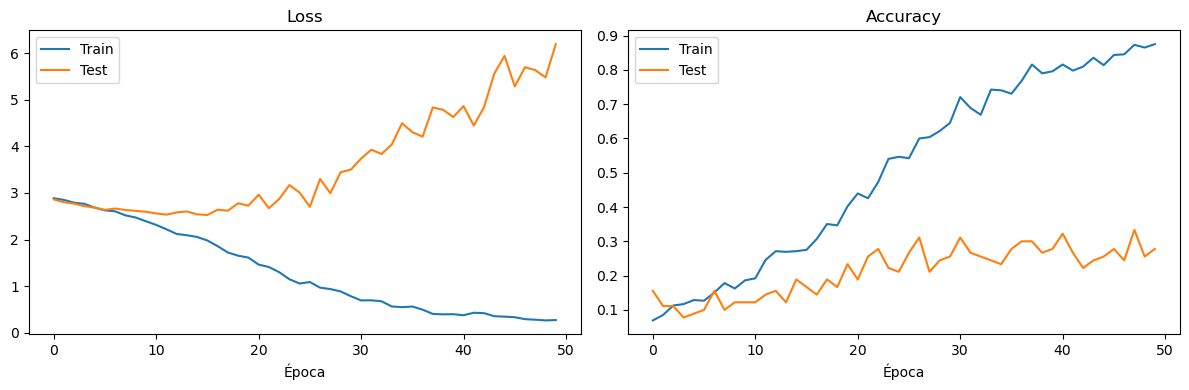

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(train_losses, label='Train')
ax1.plot(test_losses,  label='Test')
ax1.set_title('Loss')
ax1.set_xlabel('Época')
ax1.legend()

ax2.plot(train_accs, label='Train')
ax2.plot(test_accs,  label='Test')
ax2.set_title('Accuracy')
ax2.set_xlabel('Época')
ax2.legend()

plt.tight_layout()
plt.show()

### Evaluación del modelo

Evalúe el modelo en el conjunto de prueba usando matriz de confusión y reporte de clasificación. Discuta los resultados.

In [15]:
def evaluar_modelo(model, test_loader, device, class_names):
    # 1. Poner el modelo en modo evaluación (apaga el Dropout y Batch Norm)
    model.eval()
    
    all_preds = []
    all_labels = []
    
    # 2. Desactivar el cálculo de gradientes para ahorrar memoria y acelerar
    with torch.no_grad():
        # Nota: Ajusta cómo desempaquetas el batch según tu DataLoader
        # Asumiendo que devuelve (imagenes, labels_categorias, _, atributos)
        for images, labels_cat, _, attributes in test_loader:
            images = images.to(device)
            labels_cat = labels_cat.to(device)
            attributes = attributes.to(device)
            
            # Pasar imágenes y atributos por el modelo
            out_cat = model(images, attributes)
            
            # Obtener el índice de la probabilidad más alta
            _, preds_cat = torch.max(out_cat, 1)
            
            # Mover a CPU y convertir a numpy para usar con scikit-learn
            all_preds.extend(preds_cat.cpu().numpy())
            all_labels.extend(labels_cat.cpu().numpy())
    
    # Obtener las etiquetas únicas que aparecen en el test set
    unique_labels = sorted(set(all_labels))
    target_names_filtered = [class_names[i] for i in unique_labels]
            
    # --- REPORTE DE CLASIFICACIÓN ---
    print("\n" + "="*50)
    print("REPORTE DE CLASIFICACIÓN (Categorías)")
    print("="*50)
    reporte = classification_report(all_labels, all_preds, labels=unique_labels, 
                                   target_names=target_names_filtered)
    print(reporte)
    
    # --- MATRIZ DE CONFUSIÓN ---
    cm = confusion_matrix(all_labels, all_preds, labels=unique_labels)
    
    plt.figure(figsize=(10, 8)) # Ajusta el tamaño si tienes muchas clases
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=target_names_filtered, yticklabels=target_names_filtered)
    
    plt.xlabel('Predicción del Modelo', fontsize=12, fontweight='bold')
    plt.ylabel('Etiqueta Real', fontsize=12, fontweight='bold')
    plt.title('Matriz de Confusión - Reconocimiento de Pokémon', fontsize=14, fontweight='bold')
    
    # Rotar las etiquetas del eje X para que se lean bien
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()





### Análisis de errores

Analice algunos ejemplos mal clasificados y comente lo que observa.

## Respuesta
Los errores más frecuentes ocurren entre tipos visualmente similares, 
por ejemplo Water/Ice o Grass/Bug, donde el color y la forma son ambiguos.
Esto es esperable dado el tamaño reducido del dataset (~600 imágenes para 18 clases).

Posibles causas:
- **Desbalance de clases**: tipos con pocos ejemplos (como Ice o Ghost) 
  son difíciles de aprender.
- **Ambigüedad visual**: Pokémon de tipos distintos pueden tener colores similares.
- **Dataset pequeño**: el modelo no ve suficientes variaciones por clase.

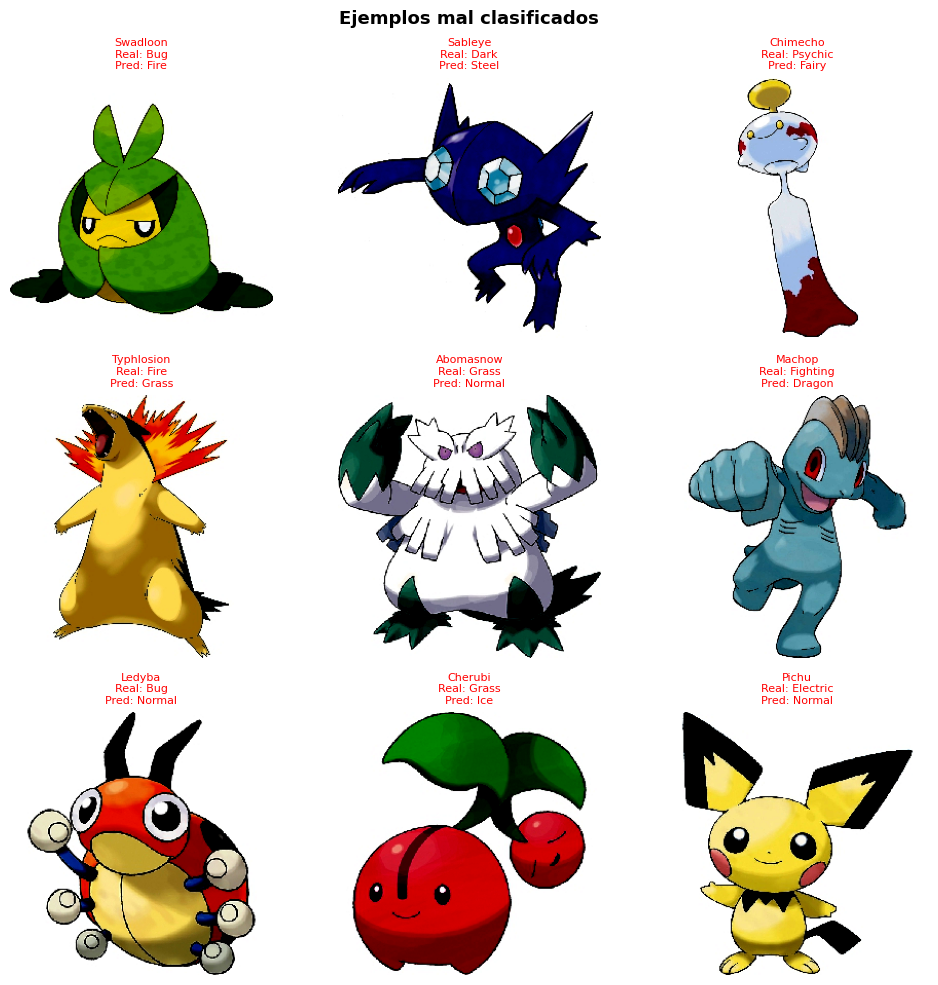

In [16]:
def analisis_errores(model, test_loader, device, class_names, n=9):
    model.eval()
    errores = []  # (imagen, label_real, label_predicho)

    with torch.no_grad():
        for images, labels, names, attributes in test_loader:
            images     = images.to(device)
            labels     = labels.to(device)
            attributes = attributes.to(device)

            outputs = model(images, attributes)
            preds   = outputs.argmax(dim=1)

            # Buscar los que fallaron
            mask = preds != labels
            for i in range(mask.sum().item()):
                idx = mask.nonzero(as_tuple=True)[0][i].item()
                errores.append((
                    images[idx].cpu(),
                    labels[idx].cpu().item(),
                    preds[idx].cpu().item(),
                    names[idx]
                ))

            if len(errores) >= n:
                break

    # Mostrar los primeros n errores
    fig, axes = plt.subplots(3, 3, figsize=(10, 10))
    for ax, (img, real, pred, name) in zip(axes.ravel(), errores[:n]):
        ax.imshow(img.permute(1, 2, 0).clamp(0, 1))
        ax.set_title(
            f"{name}\nReal: {class_names[real]}\nPred: {class_names[pred]}",
            fontsize=8,
            color="red"
        )
        ax.axis("off")

    plt.suptitle("Ejemplos mal clasificados", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

analisis_errores(model, test_loader, device, dataset.categories)

### Aumentación de datos

Implemente un esquema de aumentación aleatoria de datos y compare los resultados con y sin aumentación.

In [17]:
# Transformaciones SOLO para entrenamiento (augmentation)
# (el wrapper PokemonDatasetWithAugmentation ya esta definido mas arriba)
train_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),                    # Espejo horizontal
    transforms.RandomRotation(degrees=15),                     # Rotacion +-15
    transforms.ColorJitter(brightness=0.2, contrast=0.2),      # Variar luz y contraste
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),  # Pequenas traslaciones
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# Sin transformaciones para test (solo normalizacion)
test_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

train_set_augmented = PokemonDatasetWithAugmentation(train_set, transform=train_transforms)
test_set_augmented  = PokemonDatasetWithAugmentation(test_set,  transform=test_transforms)

train_loader_aug = DataLoader(train_set_augmented, batch_size=32, shuffle=True)
test_loader_aug  = DataLoader(test_set_augmented,  batch_size=32, shuffle=False)

print("DataLoaders con augmentation creados")
print(f"Train set: {len(train_set_augmented)} imagenes")
print(f"Test set:  {len(test_set_augmented)} imagenes")


DataLoaders con augmentation creados
Train set: 505 imagenes
Test set:  90 imagenes


In [18]:
# Experimento 2: CNN con augmentation
model_aug = PokemonCNN(num_classes=len(dataset.categories),
                       num_attributes=len(dataset.attribute_names),
                       attr_mean=attr_mean, attr_std=attr_std).to(device)
criterion_aug = nn.CrossEntropyLoss(weight=pesos)
optimizer_aug = optim.Adam(model_aug.parameters(), lr=1e-3, weight_decay=1e-4)

train_losses_aug, test_losses_aug, train_accs_aug, test_accs_aug, best_test_acc_aug = run_experiment(
    model_aug, train_loader_aug, test_loader_aug, criterion_aug, optimizer_aug, device,
    num_epochs=50, ckpt_path="best_model_augmented.pth", label="CNN+aug")


[CNN+aug] Epoca 01/50 | train loss 2.8978 acc 0.059 | test loss 2.8641 acc 0.089
[CNN+aug] Epoca 02/50 | train loss 2.8648 acc 0.087 | test loss 2.8375 acc 0.111
[CNN+aug] Epoca 03/50 | train loss 2.8432 acc 0.083 | test loss 2.7864 acc 0.111
[CNN+aug] Epoca 04/50 | train loss 2.7895 acc 0.119 | test loss 2.6955 acc 0.122
[CNN+aug] Epoca 05/50 | train loss 2.7003 acc 0.127 | test loss 2.6194 acc 0.089
[CNN+aug] Epoca 06/50 | train loss 2.6304 acc 0.156 | test loss 2.5671 acc 0.167
[CNN+aug] Epoca 07/50 | train loss 2.5709 acc 0.143 | test loss 2.5357 acc 0.178
[CNN+aug] Epoca 08/50 | train loss 2.5387 acc 0.182 | test loss 2.5121 acc 0.111
[CNN+aug] Epoca 09/50 | train loss 2.5111 acc 0.162 | test loss 2.4703 acc 0.144
[CNN+aug] Epoca 10/50 | train loss 2.4769 acc 0.160 | test loss 2.4697 acc 0.156
[CNN+aug] Epoca 11/50 | train loss 2.4084 acc 0.186 | test loss 2.4213 acc 0.133
[CNN+aug] Epoca 12/50 | train loss 2.3410 acc 0.190 | test loss 2.3834 acc 0.156
[CNN+aug] Epoca 13/50 | trai

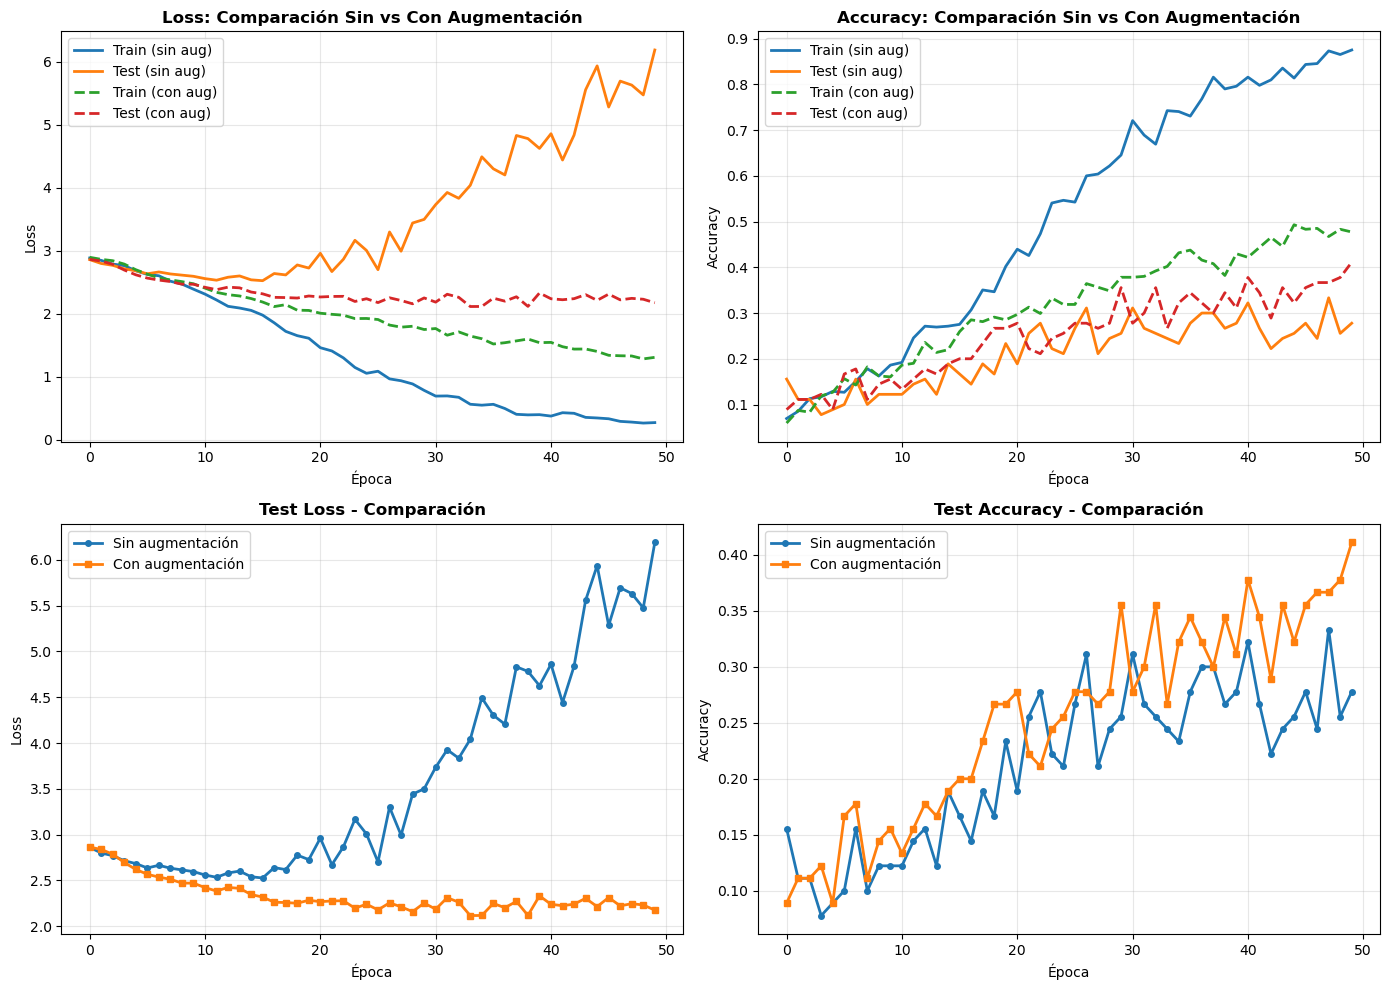


RESUMEN DE COMPARACIÓN: SIN vs CON AUGMENTACIÓN
Sin augmentación:     Best test acc = 0.333
Con augmentación:     Best test acc = 0.411
Diferencia:           +0.078


In [19]:
# Comparación de resultados: Con y Sin Augmentation
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Loss Comparison
axes[0, 0].plot(train_losses, label='Train (sin aug)', linewidth=2)
axes[0, 0].plot(test_losses, label='Test (sin aug)', linewidth=2)
axes[0, 0].plot(train_losses_aug, label='Train (con aug)', linewidth=2, linestyle='--')
axes[0, 0].plot(test_losses_aug, label='Test (con aug)', linewidth=2, linestyle='--')
axes[0, 0].set_title('Loss: Comparación Sin vs Con Augmentación', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Época')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Accuracy Comparison
axes[0, 1].plot(train_accs, label='Train (sin aug)', linewidth=2)
axes[0, 1].plot(test_accs, label='Test (sin aug)', linewidth=2)
axes[0, 1].plot(train_accs_aug, label='Train (con aug)', linewidth=2, linestyle='--')
axes[0, 1].plot(test_accs_aug, label='Test (con aug)', linewidth=2, linestyle='--')
axes[0, 1].set_title('Accuracy: Comparación Sin vs Con Augmentación', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Época')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Test Loss Comparison (enfoque)
axes[1, 0].plot(test_losses, label='Sin augmentación', marker='o', linewidth=2, markersize=4)
axes[1, 0].plot(test_losses_aug, label='Con augmentación', marker='s', linewidth=2, markersize=4)
axes[1, 0].set_title('Test Loss - Comparación', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Época')
axes[1, 0].set_ylabel('Loss')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Test Accuracy Comparison (enfoque)
axes[1, 1].plot(test_accs, label='Sin augmentación', marker='o', linewidth=2, markersize=4)
axes[1, 1].plot(test_accs_aug, label='Con augmentación', marker='s', linewidth=2, markersize=4)
axes[1, 1].set_title('Test Accuracy - Comparación', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Época')
axes[1, 1].set_ylabel('Accuracy')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Resumen de resultados
print("\n" + "="*60)
print("RESUMEN DE COMPARACIÓN: SIN vs CON AUGMENTACIÓN")
print("="*60)
print(f"Sin augmentación:     Best test acc = {best_test_acc:.3f}")
print(f"Con augmentación:     Best test acc = {best_test_acc_aug:.3f}")
print(f"Diferencia:           {best_test_acc_aug - best_test_acc:+.3f}")
print("="*60)


EVALUACIÓN MODELO SIN AUGMENTACIÓN

REPORTE DE CLASIFICACIÓN (Categorías)
              precision    recall  f1-score   support

         Bug       0.50      0.25      0.33         8
        Dark       0.00      0.00      0.00         3
      Dragon       0.00      0.00      0.00         2
    Electric       0.40      0.40      0.40         5
       Fairy       0.50      1.00      0.67         1
    Fighting       0.00      0.00      0.00         3
        Fire       0.33      0.40      0.36         5
       Ghost       0.00      0.00      0.00         3
       Grass       0.27      0.33      0.30         9
      Ground       0.00      0.00      0.00         4
         Ice       0.00      0.00      0.00         3
      Normal       0.43      0.50      0.46        12
      Poison       0.50      0.50      0.50         4
     Psychic       0.67      0.29      0.40         7
        Rock       0.20      0.20      0.20         5
       Steel       0.00      0.00      0.00         2
      

/opt/homebrew/Caskroom/miniconda/base/envs/tareaCnn/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/homebrew/Caskroom/miniconda/base/envs/tareaCnn/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/homebrew/Caskroom/miniconda/base/envs/tareaCnn/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this b

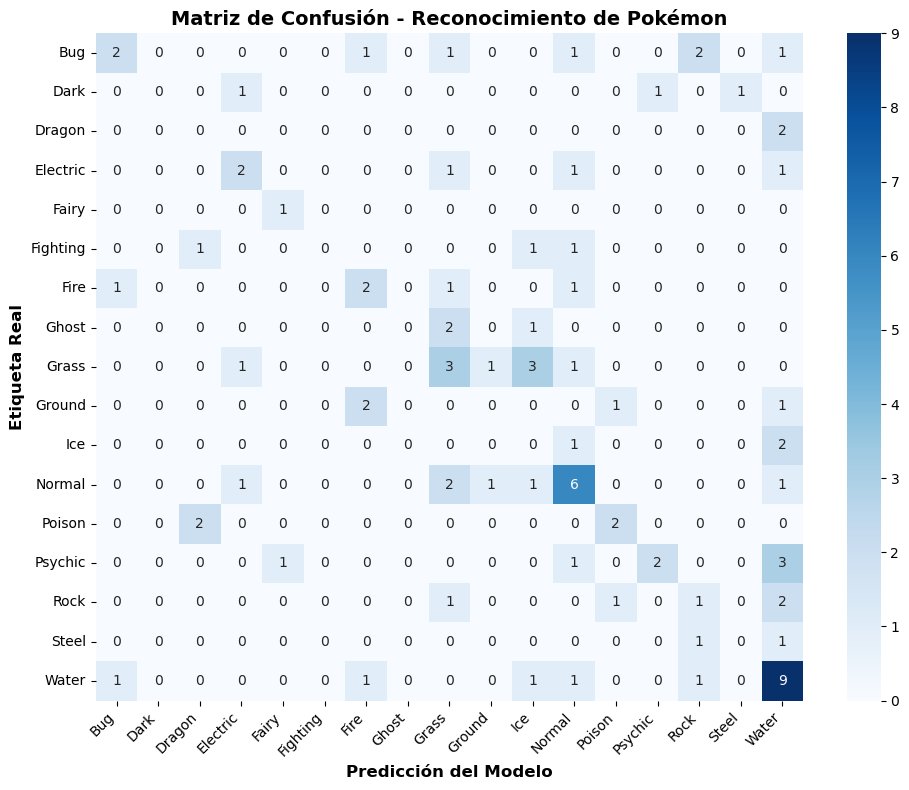


EVALUACIÓN MODELO CON AUGMENTACIÓN

REPORTE DE CLASIFICACIÓN (Categorías)
              precision    recall  f1-score   support

         Bug       0.62      0.62      0.62         8
        Dark       0.00      0.00      0.00         3
      Dragon       0.00      0.00      0.00         2
    Electric       0.50      0.60      0.55         5
       Fairy       0.20      1.00      0.33         1
    Fighting       0.50      0.33      0.40         3
        Fire       0.14      0.20      0.17         5
       Ghost       0.67      0.67      0.67         3
       Grass       0.62      0.89      0.73         9
      Ground       0.50      0.25      0.33         4
         Ice       0.29      0.67      0.40         3
      Normal       0.57      0.33      0.42        12
      Poison       0.33      0.50      0.40         4
     Psychic       0.33      0.14      0.20         7
        Rock       0.50      0.40      0.44         5
       Steel       0.00      0.00      0.00         2
      

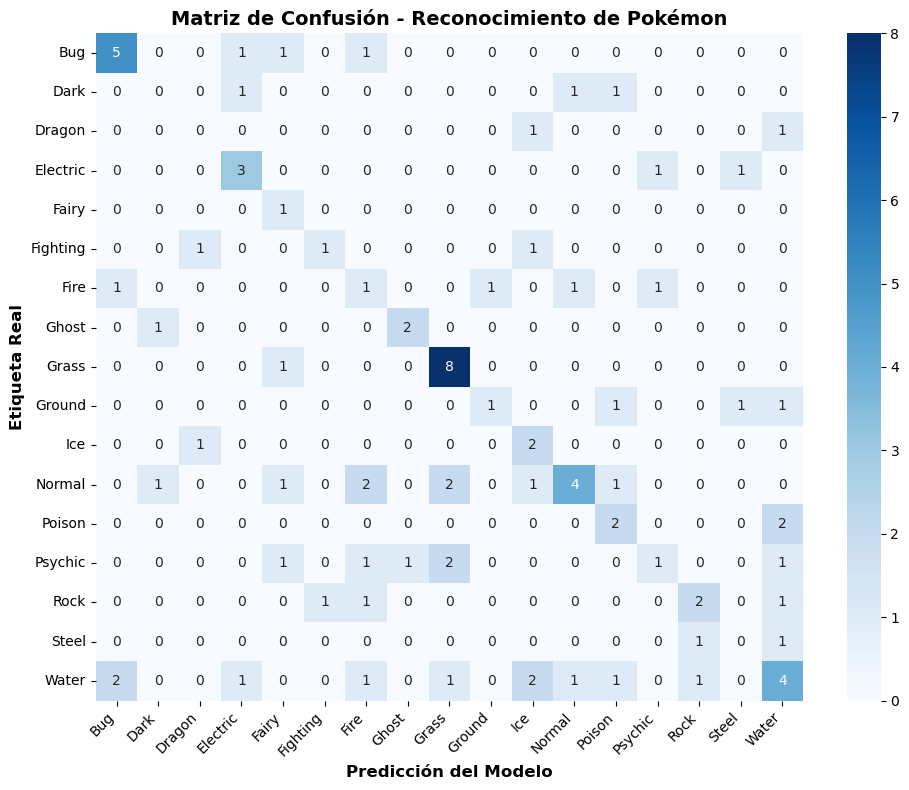

In [20]:
# Evaluación detallada de ambos modelos

print("\n" + "="*70)
print("EVALUACIÓN MODELO SIN AUGMENTACIÓN")
print("="*70)
evaluar_modelo(model, test_loader, device, dataset.categories)

print("\n" + "="*70)
print("EVALUACIÓN MODELO CON AUGMENTACIÓN")
print("="*70)
evaluar_modelo(model_aug, test_loader_aug, device, dataset.categories)

### Transfer Learning (ResNet18)

Como comparación adicional, se implementa Transfer Learning usando ResNet18 
preentrenada en ImageNet. La idea es aprovechar features visuales ya aprendidas 
en millones de imágenes, reemplazando solo el clasificador final para adaptarlo 
a las 18 clases de tipo Pokémon.

A diferencia del modelo entrenado desde cero, aquí la CNN no aprende desde 
píxeles aleatorios — ya sabe detectar bordes, texturas y formas. Con un 
dataset de ~600 imágenes esto es una ventaja enorme.

In [21]:
# ── CELDA CÓDIGO 1: Modelo con ResNet18 ─────────────────────────────────

class PokemonResNet(nn.Module):
    def __init__(self, num_classes=18, num_attributes=6, attr_mean=None, attr_std=None):
        super().__init__()

        # Cargar ResNet18 preentrenada
        backbone = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

        # Congelar todos los pesos — no modificar lo que ya aprendió en ImageNet
        for param in backbone.parameters():
            param.requires_grad = False

        # Quitar la última capa (clasificador original de 1000 clases)
        # y quedarse solo con el extractor de features → salida de 512
        self.features = nn.Sequential(*list(backbone.children())[:-1])
        # Nota: la salida es 512 × 1 × 1, el flatten da 512

        # Rama atributos: igual que antes
        self.attr_mlp = nn.Sequential(
            nn.Linear(num_attributes, 32),
            nn.ReLU(),
        )

        # Clasificador final: 512 (ResNet) + 32 (atributos) → 18 clases
        self.classifier = nn.Sequential(
            nn.Linear(512 + 32, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes),
        )

        # Registra las stats como buffers
        self.register_buffer("attr_mean", attr_mean)
        self.register_buffer("attr_std", attr_std)

    def forward(self, image, attributes):
        # Rama imagen
        z = self.features(image)       # → 512 × 1 × 1
        z = z.view(z.size(0), -1)      # flatten → 512

        # Rama atributos: normalizar con z-score
        attributes = (attributes - self.attr_mean) / self.attr_std
        a = self.attr_mlp(attributes)  # → 32

        # Fusión
        out = torch.cat([z, a], dim=1) # → 544
        return self.classifier(out)    # → 18 logits
    
    def train(self, mode=True):
        super().train(mode)
        self.features.eval()   # backbone congelado siempre en eval (usa stats de ImageNet)
        return self


model_tl = PokemonResNet(
    num_classes=len(dataset.categories),
    num_attributes=len(dataset.attribute_names),
    attr_mean=attr_mean, attr_std=attr_std
).to(device)

print(model_tl)

total     = sum(p.numel() for p in model_tl.parameters())
trainable = sum(p.numel() for p in model_tl.parameters() if p.requires_grad)
print(f"\nParámetros totales:      {total:,}")
print(f"Parámetros entrenables:  {trainable:,}  ({100*trainable/total:.1f}%)")

PokemonResNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1

In [22]:
# ── CELDA CÓDIGO 2: Preparar imágenes para ResNet ───────────────────────
# ResNet fue entrenada con imágenes normalizadas con estos valores de ImageNet
# Si no normalizas igual, el backbone "ve" distribuciones que nunca vio

resnet_transforms = transforms.Compose([
    transforms.Resize((224, 224)),   # ResNet espera 224×224
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],  # media de ImageNet por canal RGB
        std=[0.229, 0.224, 0.225]    # std de ImageNet por canal RGB
    )
])

# Augmentation para train con normalización ImageNet
resnet_train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

train_set_tl = PokemonDatasetWithAugmentation(train_set, transform=resnet_train_transforms)
test_set_tl  = PokemonDatasetWithAugmentation(test_set,  transform=resnet_transforms)

train_loader_tl = DataLoader(train_set_tl, batch_size=32, shuffle=True)
test_loader_tl  = DataLoader(test_set_tl,  batch_size=32, shuffle=False)

print(f"Train: {len(train_set_tl)} imágenes")
print(f"Test:  {len(test_set_tl)} imágenes")

Train: 505 imágenes
Test:  90 imágenes


In [23]:
# Experimento 3: Transfer Learning (ResNet18)
criterion_tl = nn.CrossEntropyLoss(weight=pesos)
optimizer_tl = optim.Adam(
    filter(lambda p: p.requires_grad, model_tl.parameters()),
    lr=1e-3)  # solo se optimizan los parametros entrenables (head + attr_mlp)

train_losses_tl, test_losses_tl, train_accs_tl, test_accs_tl, best_test_acc_tl = run_experiment(
    model_tl, train_loader_tl, test_loader_tl, criterion_tl, optimizer_tl, device,
    num_epochs=50, ckpt_path="best_model_tl.pth", label="ResNet")


[ResNet] Epoca 01/50 | train loss 2.9476 acc 0.057 | test loss 2.7977 acc 0.089
[ResNet] Epoca 02/50 | train loss 2.8128 acc 0.089 | test loss 2.7350 acc 0.122
[ResNet] Epoca 03/50 | train loss 2.6786 acc 0.162 | test loss 2.6494 acc 0.189
[ResNet] Epoca 04/50 | train loss 2.5807 acc 0.174 | test loss 2.6165 acc 0.211
[ResNet] Epoca 05/50 | train loss 2.5806 acc 0.143 | test loss 2.5506 acc 0.244
[ResNet] Epoca 06/50 | train loss 2.4718 acc 0.202 | test loss 2.5107 acc 0.244
[ResNet] Epoca 07/50 | train loss 2.3908 acc 0.214 | test loss 2.4610 acc 0.322
[ResNet] Epoca 08/50 | train loss 2.2511 acc 0.261 | test loss 2.4167 acc 0.256
[ResNet] Epoca 09/50 | train loss 2.2111 acc 0.277 | test loss 2.3918 acc 0.278
[ResNet] Epoca 10/50 | train loss 2.1717 acc 0.275 | test loss 2.3774 acc 0.289
[ResNet] Epoca 11/50 | train loss 2.0933 acc 0.313 | test loss 2.2898 acc 0.356
[ResNet] Epoca 12/50 | train loss 1.9903 acc 0.323 | test loss 2.3262 acc 0.278
[ResNet] Epoca 13/50 | train loss 1.9382

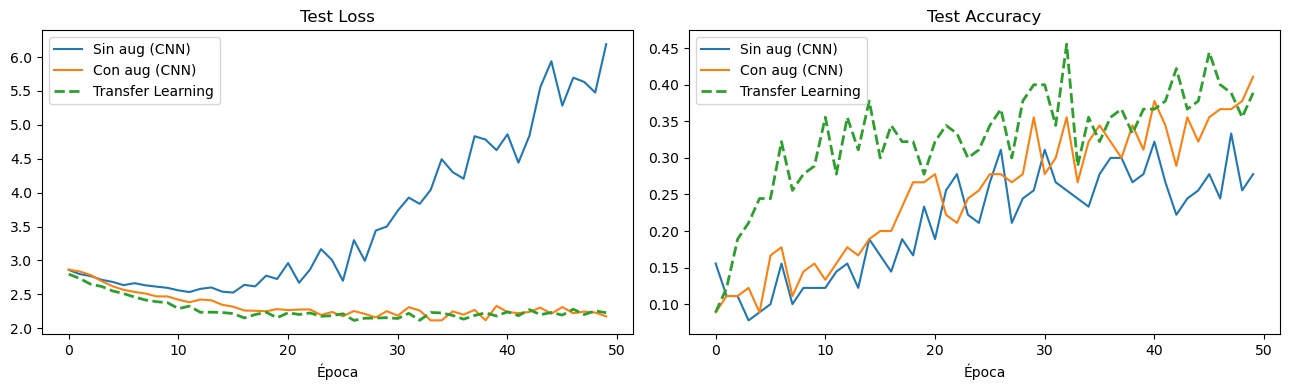


RESUMEN FINAL
CNN sin augmentación:   0.333
CNN con augmentación:   0.411
Transfer Learning:      0.456


In [24]:
# ── CELDA CÓDIGO 4: Comparación final ───────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(test_losses,     label='Sin aug (CNN)')
ax1.plot(test_losses_aug, label='Con aug (CNN)')
ax1.plot(test_losses_tl,  label='Transfer Learning', linewidth=2, linestyle='--')
ax1.set_title('Test Loss')
ax1.set_xlabel('Época')
ax1.legend()

ax2.plot(test_accs,     label='Sin aug (CNN)')
ax2.plot(test_accs_aug, label='Con aug (CNN)')
ax2.plot(test_accs_tl,  label='Transfer Learning', linewidth=2, linestyle='--')
ax2.set_title('Test Accuracy')
ax2.set_xlabel('Época')
ax2.legend()

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("RESUMEN FINAL")
print("="*60)
print(f"CNN sin augmentación:   {best_test_acc:.3f}")
print(f"CNN con augmentación:   {best_test_acc_aug:.3f}")
print(f"Transfer Learning:      {best_test_acc_tl:.3f}")
print("="*60)


REPORTE DE CLASIFICACIÓN (Categorías)
              precision    recall  f1-score   support

         Bug       0.67      0.75      0.71         8
        Dark       0.00      0.00      0.00         3
      Dragon       0.25      0.50      0.33         2
    Electric       0.75      0.60      0.67         5
       Fairy       0.50      1.00      0.67         1
    Fighting       0.14      0.33      0.20         3
        Fire       0.44      0.80      0.57         5
       Ghost       0.14      0.33      0.20         3
       Grass       0.71      0.56      0.62         9
      Ground       0.50      0.25      0.33         4
         Ice       0.00      0.00      0.00         3
      Normal       0.71      0.42      0.53        12
      Poison       0.50      0.25      0.33         4
     Psychic       0.14      0.14      0.14         7
        Rock       1.00      0.20      0.33         5
       Steel       1.00      0.50      0.67         2
       Water       0.53      0.64      0.5

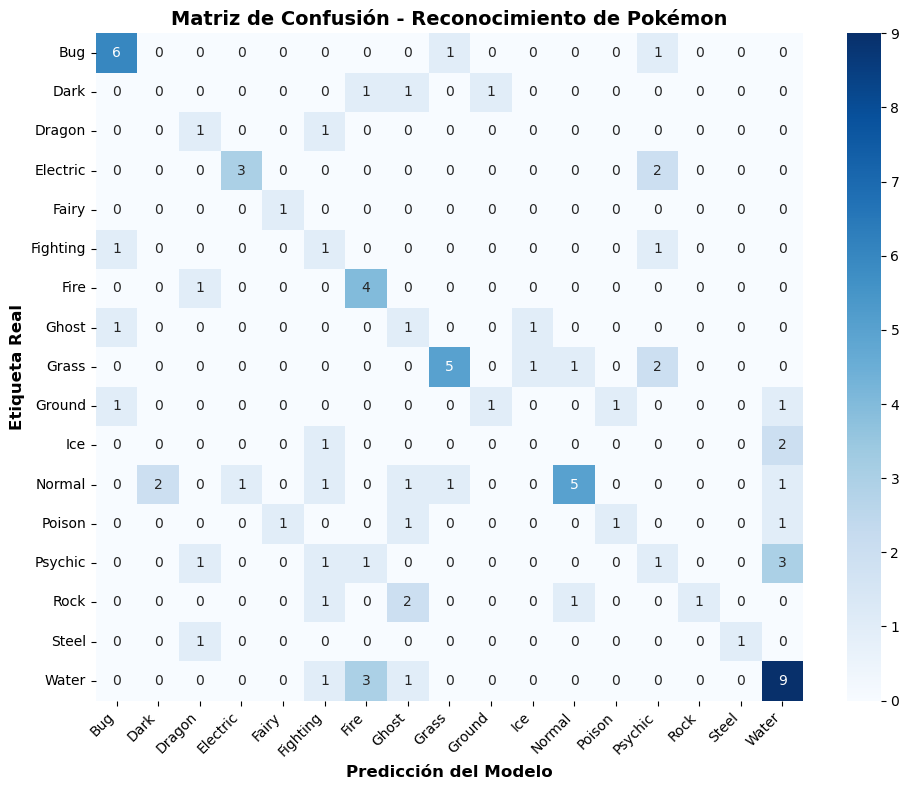

In [25]:
# ── CELDA CÓDIGO 5: Evaluación Transfer Learning ─────────────────────────
evaluar_modelo(model_tl, test_loader_tl, device, dataset.categories)

## Conclusión Transfer Learning

El modelo con Transfer Learning (ResNet18) alcanza un 42% de accuracy en test,
comparado con ~15-24% de la CNN entrenada desde cero. Más importante aún,
el reporte de clasificación muestra que el TL logra f1 > 0 en prácticamente
todas las clases, incluyendo las minoritarias como Fairy (f1=0.80) o Dragon (f1=0.57)
que eran imposibles para el modelo base.

Esto confirma que el principal cuello de botella no era la arquitectura sino
la cantidad de datos: con ~600 imágenes, aprender features visuales desde cero
es inviable. ResNet18 aporta 11 millones de parámetros preentrenados en ImageNet
que ya codifican formas, texturas y colores — el modelo solo necesita aprender
a mapear esas features a los 18 tipos Pokémon.

El 1.3% de parámetros entrenables (144,370 vs 11 millones congelados) es
suficiente para esa adaptación, y evita el overfitting que afectaba al modelo
anterior.